In [1]:
%load_ext autoreload
%autoreload 2

# Self Trained Gradient Descent Logistic Regression - Experiments

The estimation procedure is given by

\begin{align}
\theta_0 &= \operatorname*{argmin}_{\theta \in \mathbb{R}^{d+1}} \frac{1}{N} \sum_{i=1}^N \ell(Y_i u_{\theta}(X_i)) + \frac{\lambda}{2}\| w \|^2, & \tag{1} \\
\theta_{t+1} &= \theta_t - \eta \nabla_{\theta} R_t( \theta_t), & \text{for } t \geq 0. \tag{2}
\end{align}

Where the augmented loss at time $ t \geq 0$ is given by
\begin{align} 
R_t(\theta) = \frac{1}{N} \sum_{i=1}^N \ell(Y_i u_{\theta}(X_i)) + \frac{\gamma}{|I_t|} \sum_{j \in I_t} \ell(\hat Y_{t,j} u_{\theta}(X_i)) + \frac{\lambda}{2}\| w \|^2, \tag{3}
\end{align}
with the indices of pseudo labeled data
\begin{align} 
I_t = \{ j \in [\![1, M]\!] : |u_{\theta_t}(X_j)| \geq \kappa \}. \tag{4}
\end{align}

* The initialization step $(1)$ performs $\ell^2$-penalized logistic regression on the labeled data. 
* The recursive step $(2)$ perform one step of gradient descent using the gradient of the augmented loss $(3)$, augmented with pseudo labeled data from the previous iteration $(4)$. 


The data is generated by the model:
$$ X = Y \mu + \Sigma^{1/2} U,$$
where $Y \sim \text{Rad}(p)$ independent of $ U \sim \mathcal{N}(0,I_d)$.

In [1]:
import numpy as np
from dgp import SpikedIsotropic
from utils import run_experiment, plot_experiment
from algorithms import GradientStepSelfTrainer

import warnings
warnings.filterwarnings("ignore")

## Isotropic Model Experiments

$$ \Sigma = \sigma^2 I_d$$

In [4]:
d = 500
s = 1

p = 0.5

spikes_val = [0.0 * i + 0.0 for i in range(s)] 

spikes_vect = [np.zeros(d) for _ in range(s)]
for i in range(s):
    spikes_vect[i][i] = 1.0

# Aligned Signal: The signal lives exclusively in the top 5 spiked dimensions.
# Norm is constrained so the problem is not trivially separable.
mu = np.zeros(d)
mu[0:5] = 0.5  # ||mu|| = sqrt(5 * 0.25) = 1.11

sigma = 1.0
seed = 42

data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

# Setup Base Parameters
base_params = {
    'p': 0.75,
    'gamma': 0.5,
    'lambda': 0.01,
    'eta': 1.0
}

runs = 10
monte_carlo_seeds = list(range(runs))
T = 500
N = 100
M = 10000
N_test = 5000

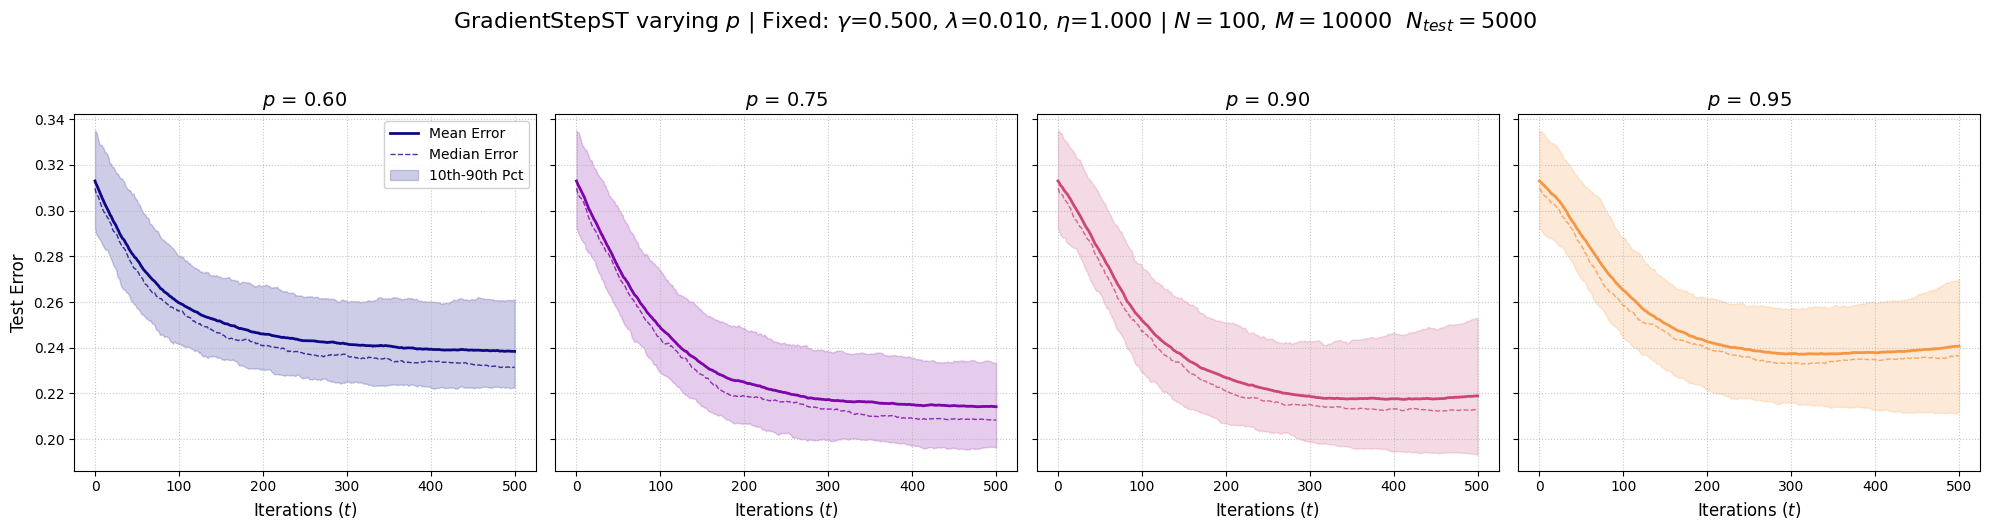

In [ ]:
# Define the sweep
target_param = 'p'
test_values = [0.6, 0.75, 0.9, 0.95]

# Run 
res_array = run_experiment(
    data_gen=data, algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test, T=T,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
)

# Plot
plot_experiment(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

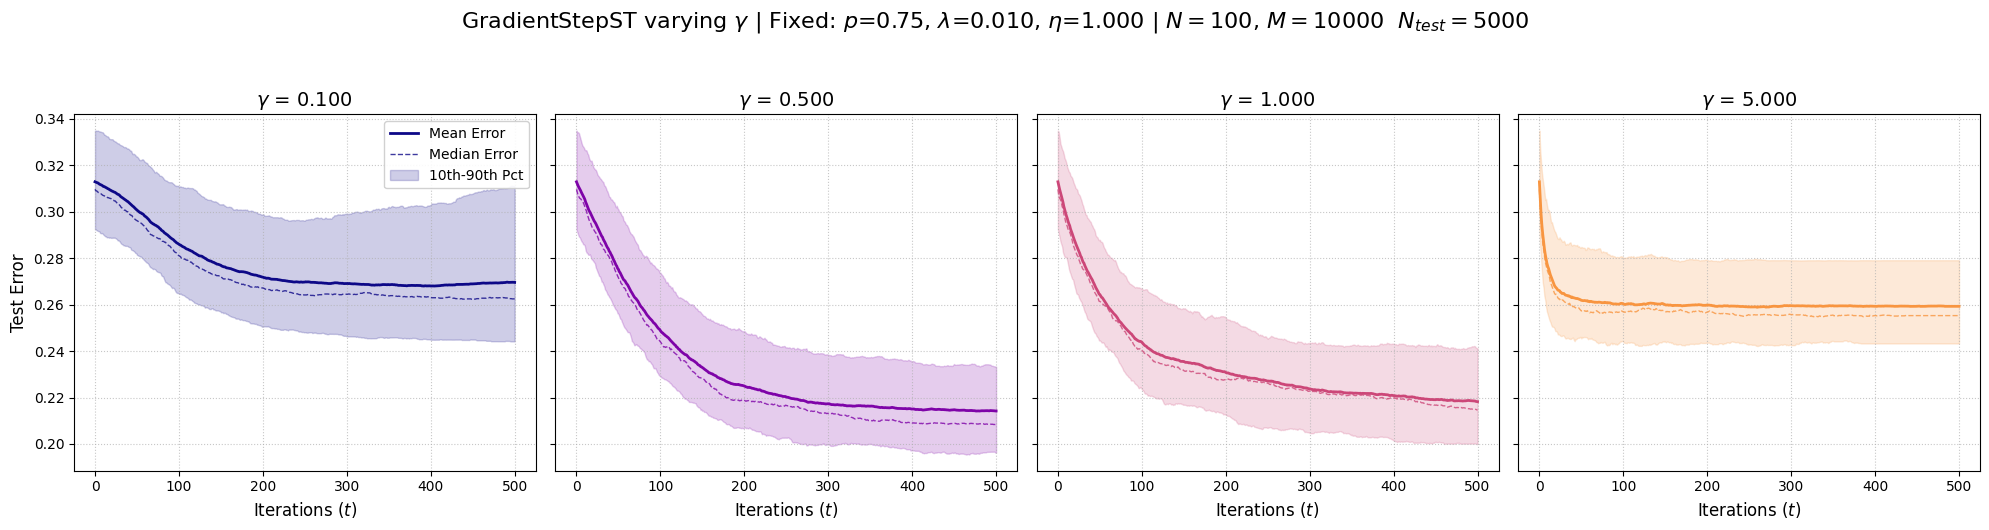

In [ ]:
# Define the sweep
target_param = 'gamma'
test_values = [0.1, 0.5, 1.0, 5.0]

# Run 
res_array = run_experiment(
    data_gen=data, algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test, T=T,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
)

# Plot
plot_experiment(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

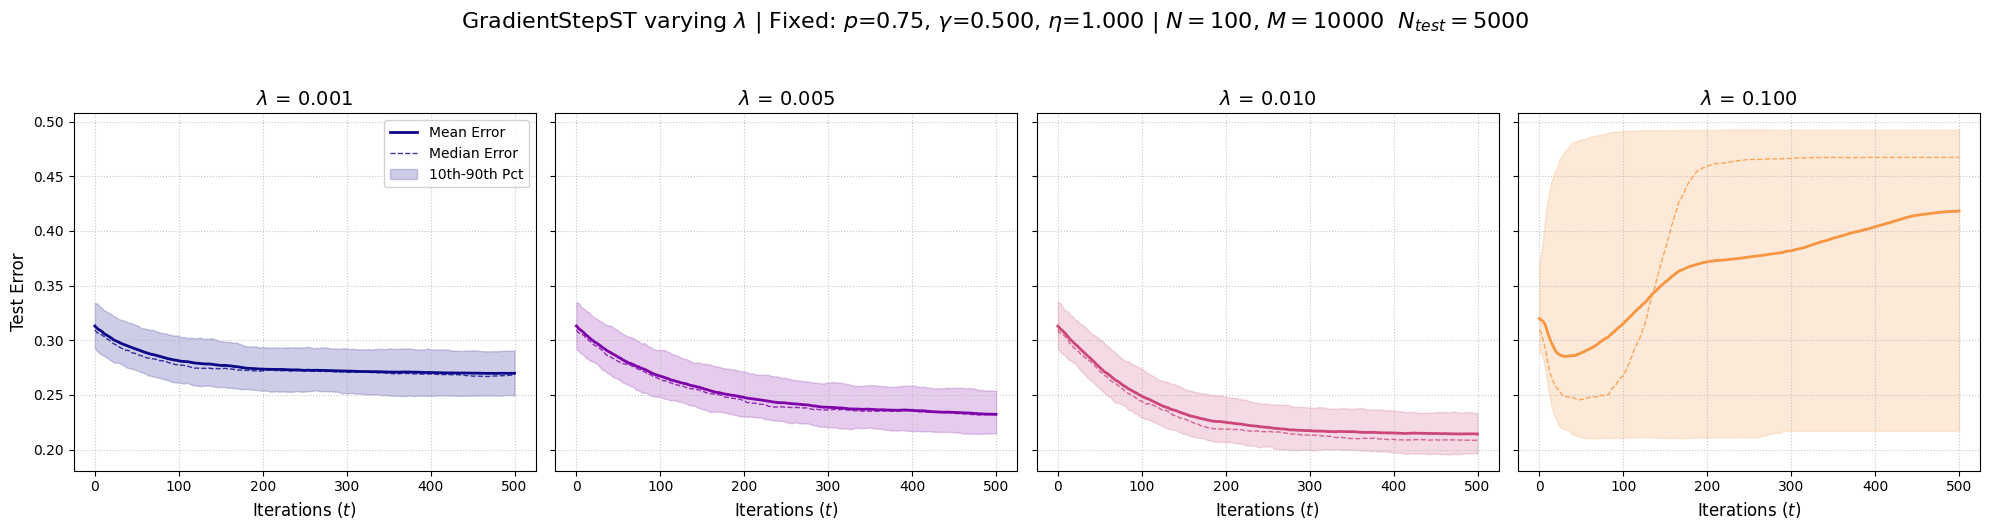

In [ ]:
# Define the sweep
target_param = 'lambda'
test_values = [0.001, 0.005, 0.01, 0.1]

# Run 
res_array = run_experiment(
    data_gen=data, algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test, T=T,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
)

# Plot
plot_experiment(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## Spiked Isotropic Model Experiments

$$ \Sigma = \sigma^2 I_d + \sum_{k=1}^s \sigma_k^2 v_k v_k^\top  $$

In [ ]:
d = 500
s = 10

spikes_val = [2.0 * i + 2.0 for i in range(s)] 

spikes_vect = [np.zeros(d) for _ in range(s)]
for i in range(s):
    spikes_vect[i][i] = 1.0

# Aligned Signal: The signal lives exclusively in the top 5 spiked dimensions.
# Norm is constrained so the problem is not trivially separable.
mu = np.zeros(d)
mu[0:5] = 0.5  # ||mu|| = sqrt(5 * 0.25) = 1.11

sigma = 1.0
seed = 42

data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

# Setup Base Parameters
base_params = {
    'p': 0.75,
    'gamma': 0.5,
    'lambda': 0.01,
    'eta': 1.0
}

runs = 10
monte_carlo_seeds = list(range(runs))
T = 500
N = 100
M = 10000
N_test = 5000

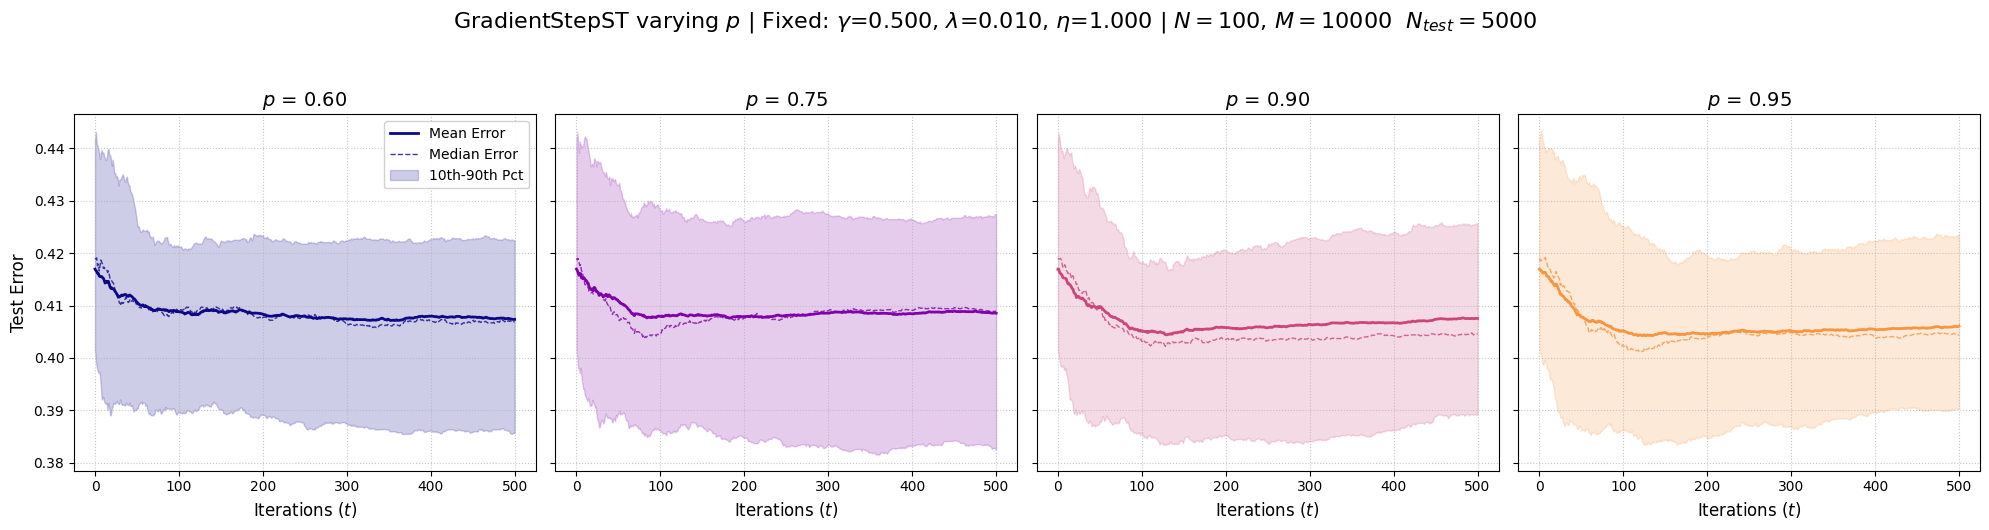

In [ ]:
# Define the sweep
target_param = 'p'
test_values = [0.6, 0.75, 0.9, 0.95]

# Run 
res_array = run_experiment(
    data_gen=data, algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test, T=T,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
)

# Plot
plot_experiment(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

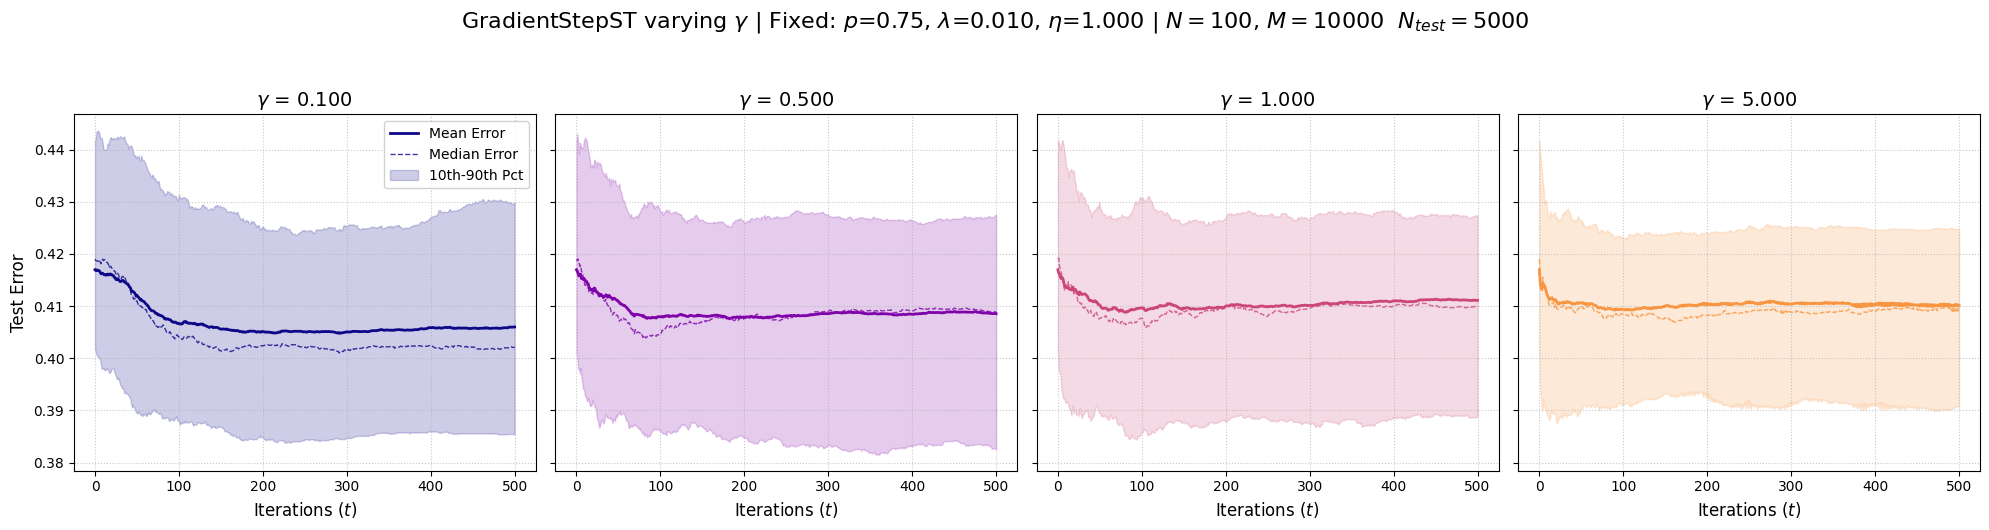

In [ ]:
# Define the sweep
target_param = 'gamma'
test_values = [0.1, 0.5, 1.0, 5.0]

# Run 
res_array = run_experiment(
    data_gen=data, algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test, T=T,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
)

# Plot
plot_experiment(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

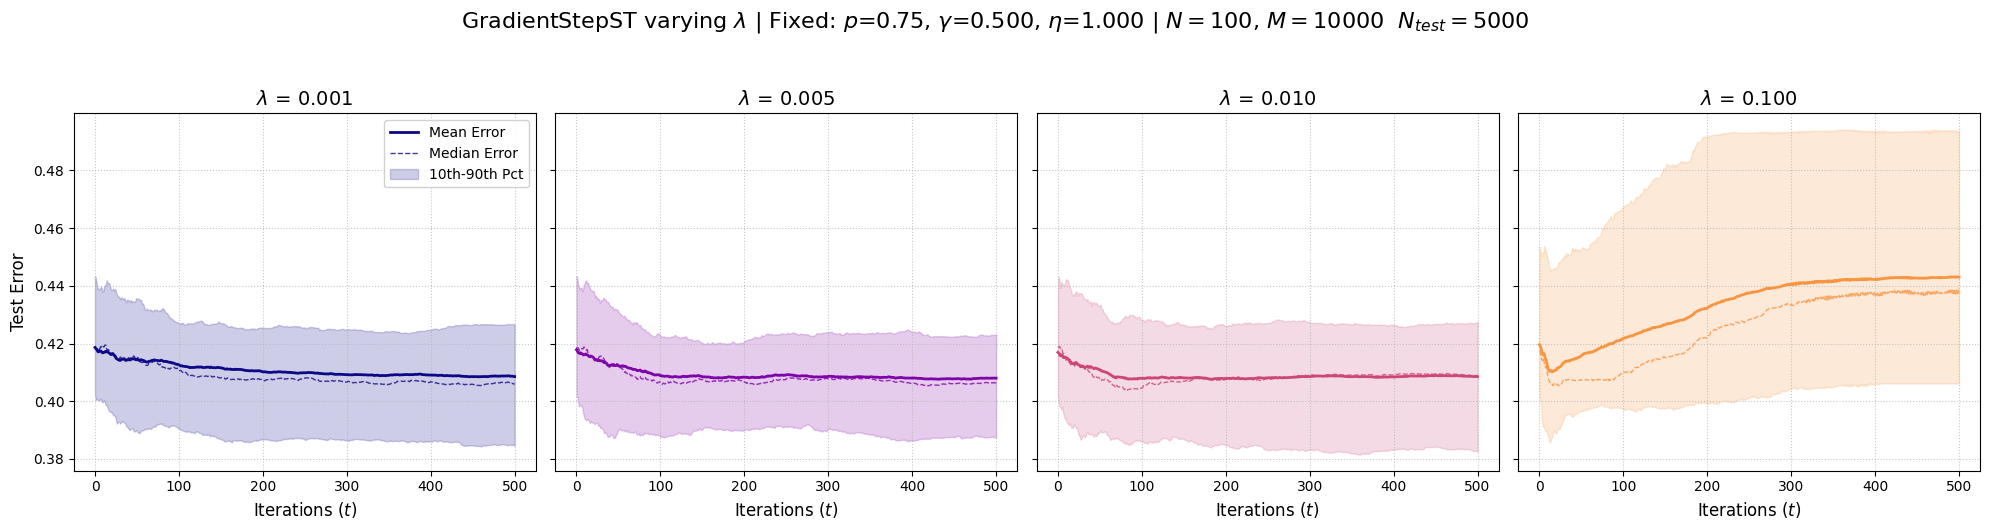

In [ ]:
# Define the sweep
target_param = 'lambda'
test_values = [0.001, 0.005, 0.01, 0.1]

# Run 
res_array = run_experiment(
    data_gen=data, algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test, T=T,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
)

# Plot
plot_experiment(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

***
# Unequal priors

$$ Y \sim \text{Rad}(p), \quad p \in \{ 0.5, 0.4, 0.3, 0.2, 0.1 \} $$

In [48]:
d = 500
s = 1

spikes_val = [0.0 * i + 0.0 for i in range(s)] 

spikes_vect = [np.zeros(d) for _ in range(s)]
for i in range(s):
    spikes_vect[i][i] = 1.0

# Aligned Signal: The signal lives exclusively in the top 5 spiked dimensions.
# Norm is constrained so the problem is not trivially separable.
mu = np.zeros(d)
mu[0:5] = 0.5  # ||mu|| = sqrt(5 * 0.25) = 1.11

sigma = 1.0
seed = 42

# Setup Base Parameters

runs = 10
monte_carlo_seeds = list(range(runs))
T = 500
N = 100
M = 10000
N_test = 5000

base_params = {
    'p': 0.9,
    'gamma': 1.0,
    'lambda': 0.01,
    'eta': 1.0
}

## $p=0.5$

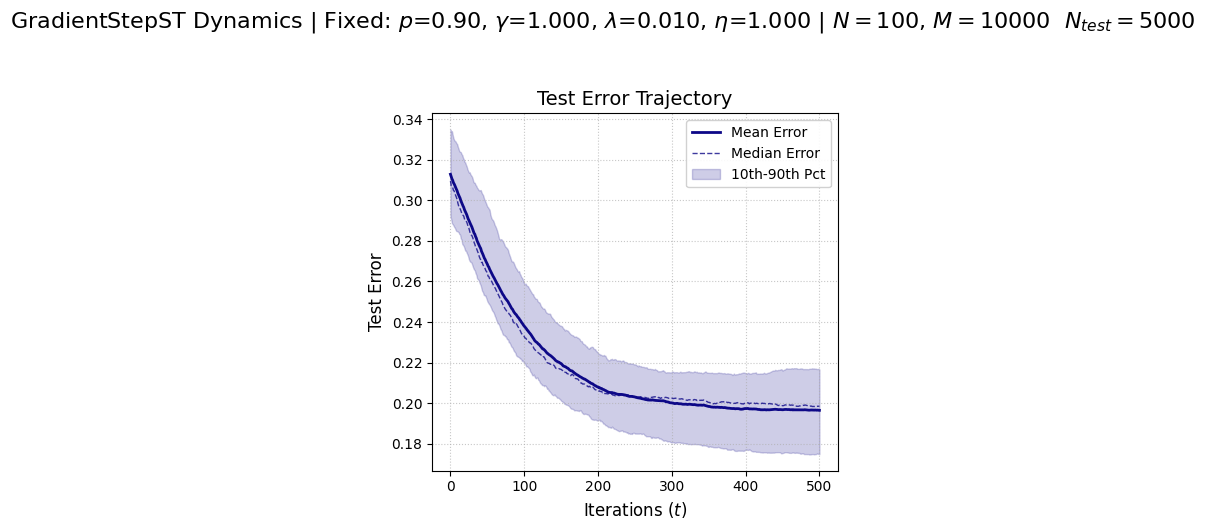

In [44]:
p = 0.5
data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## $p = 0.4$

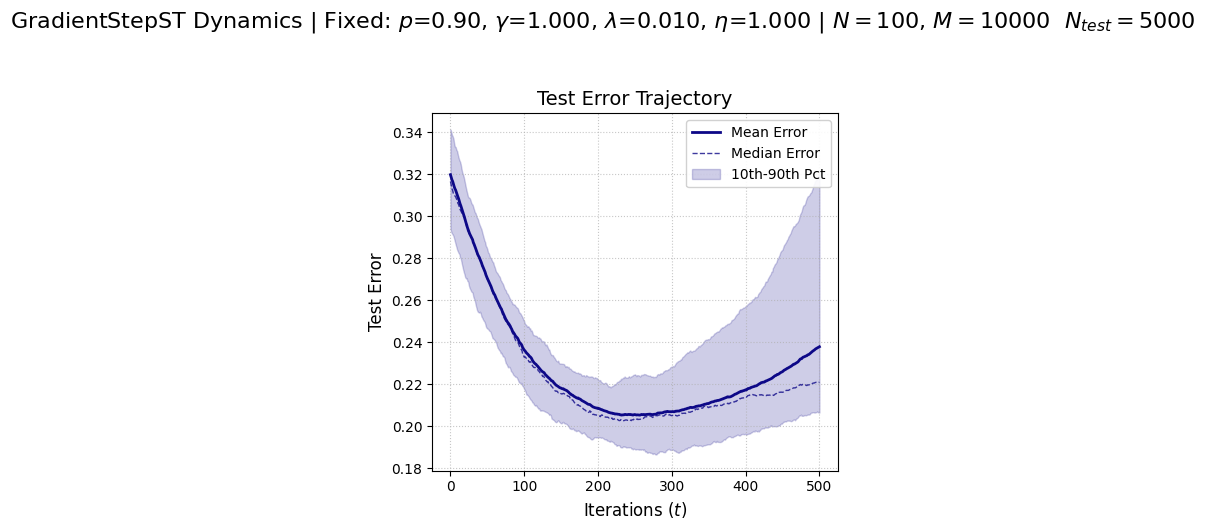

In [45]:
p = 0.4
data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## $p = 0.3$

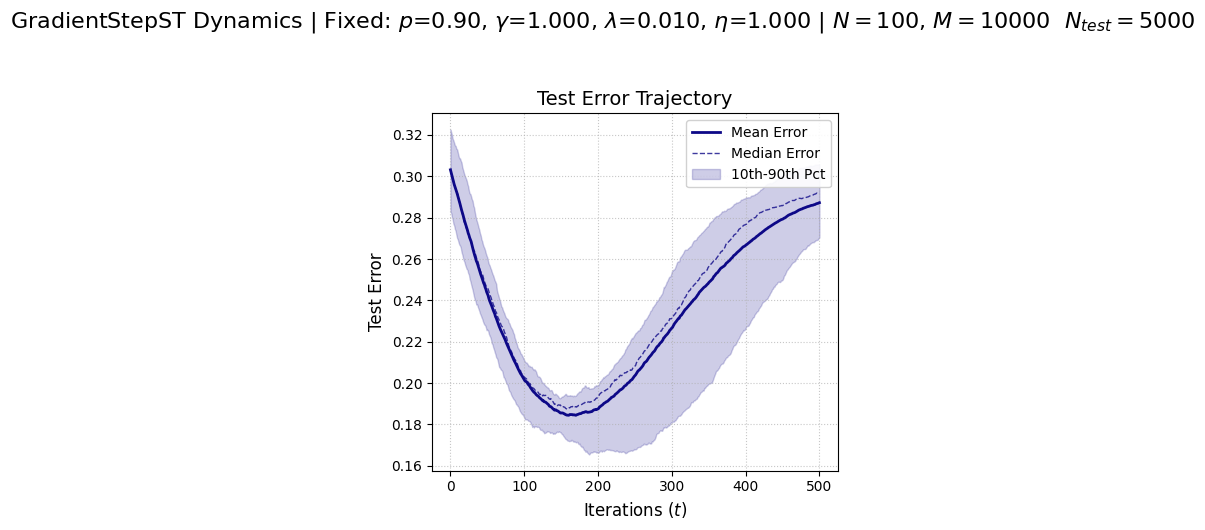

In [46]:
p = 0.3
data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## $p=0.2$

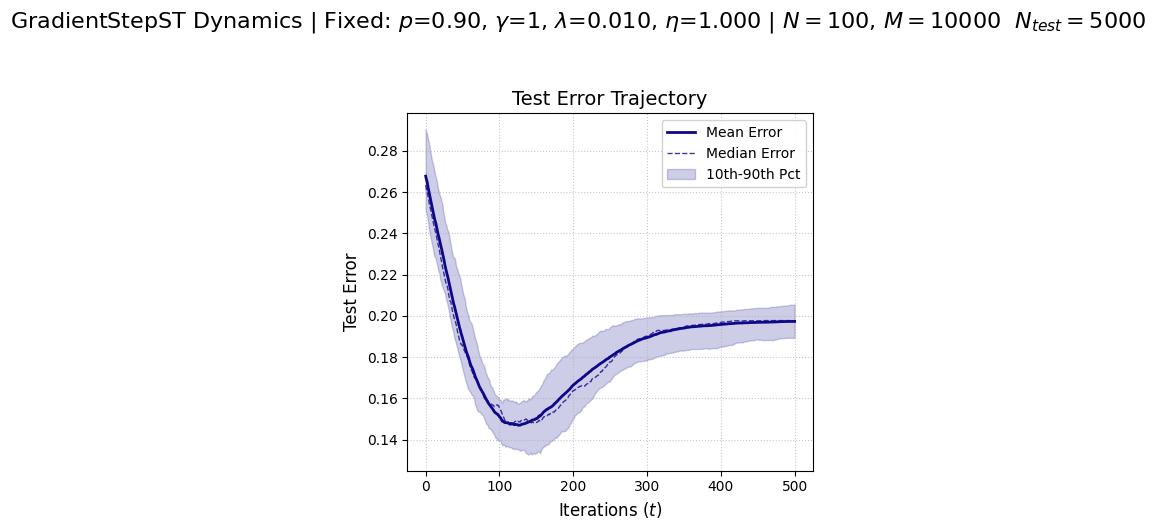

In [42]:
p = 0.2
data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

base_params = {
    'p': 0.9,
    'gamma': 1,
    'lambda': 0.01,
    'eta': 1.0
}

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## $p=0.1$

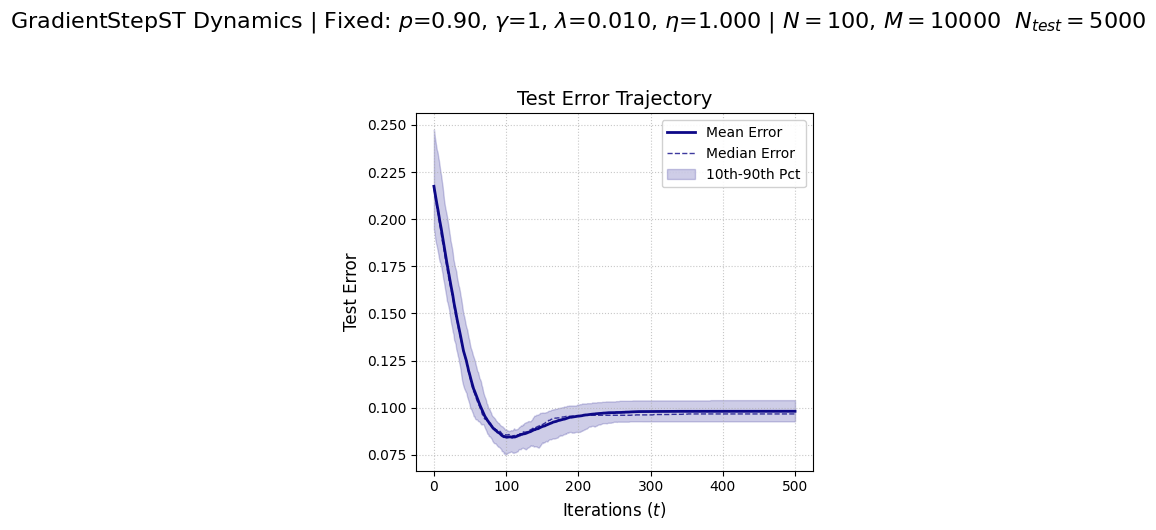

In [47]:
p = 0.1
data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

base_params = {
    'p': 0.9,
    'gamma': 1,
    'lambda': 0.01,
    'eta': 1.0
}

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

***
# Varying Hyperparameters ($\kappa, \gamma, \lambda, \eta$)

Recall:
* $\kappa \in (0, \infty)$ is the confidence threshold for the pseudo-labels (expressed in terms of log-odds).
* $\gamma \in (0,\infty)$ is the weight of the pseudo-labeled loss in the augmented loss.
* $\lambda \in (0,\infty)$ is the weight of the $\ell^2$-penalty.
* $\eta \in (0,\infty)$ is the step size in the gradient step. 

To make $\kappa$ more interpretable, we vary the confidence threshold in terms of $p \in (1/2,1)$, where
$$ \kappa = \log \left( \frac{p}{1-p} \right). $$

In [2]:
p = 0.5

d = 500
s = 1

spikes_val = [0.0 * i + 0.0 for i in range(s)] 

spikes_vect = [np.zeros(d) for _ in range(s)]
for i in range(s):
    spikes_vect[i][i] = 1.0

# Aligned Signal: The signal lives exclusively in the top 5 spiked dimensions.
# Norm is constrained so the problem is not trivially separable.
mu = np.zeros(d)
mu[0:5] = 0.5  # ||mu|| = sqrt(5 * 0.25) = 1.11

sigma = 1.0
seed = 42

data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, p, seed)

# Setup Base Parameters


runs = 10
monte_carlo_seeds = list(range(runs))
T = 500
N = 100
M = 10000
N_test = 5000

## Fixed Parameters (Baseline)

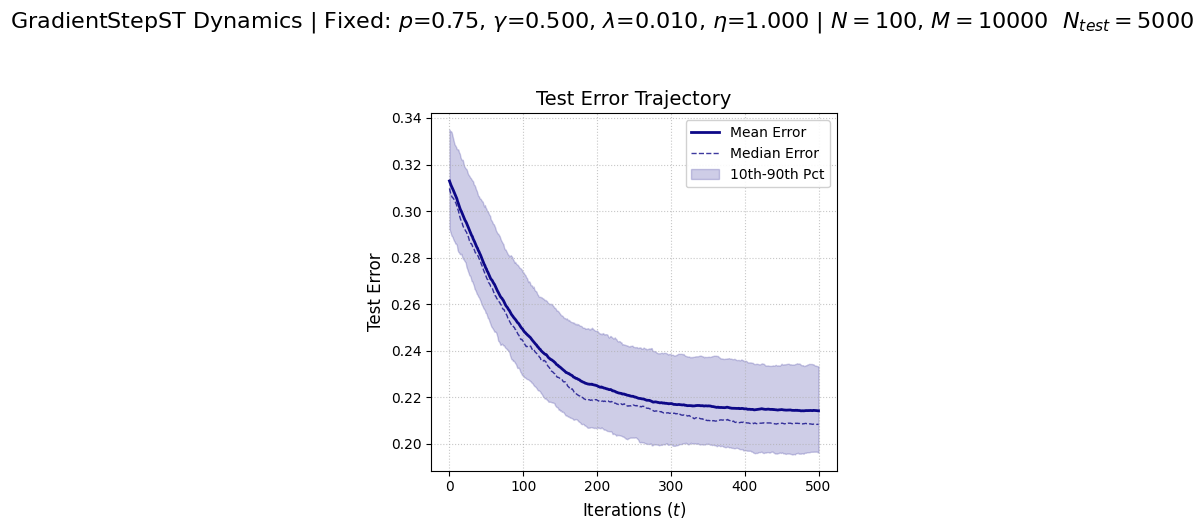

In [13]:
# Create a linear decay schedule for lambda

base_params = {
    'p': 0.75,
    'gamma': 0.5,
    'lambda': 0.01,
    'eta': 1.0
}

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## Varying $p$

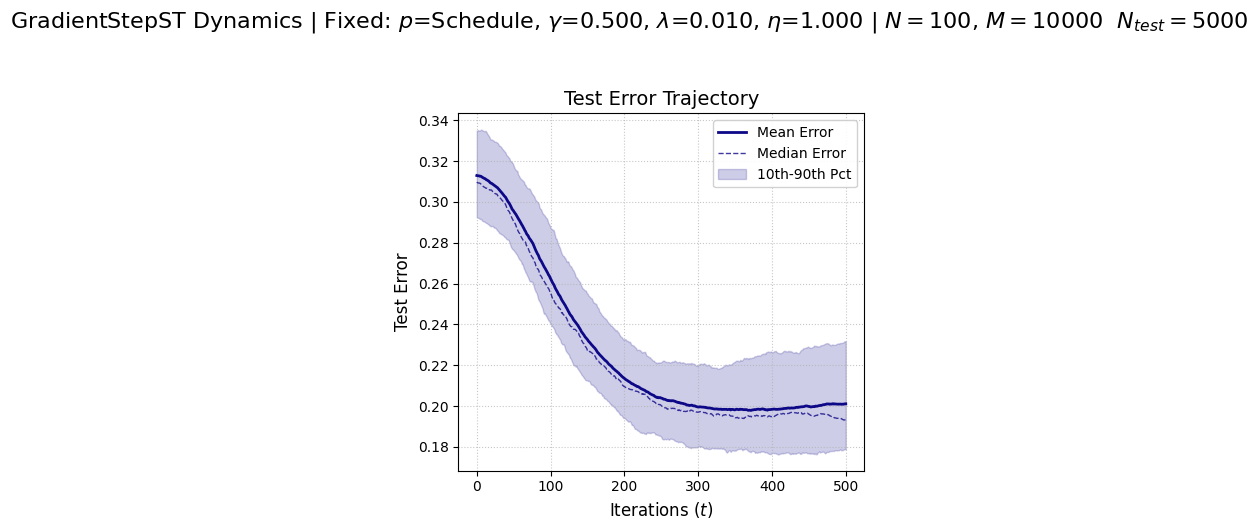

In [21]:
# Create a linear decay schedule for lambda
p_schedule = np.linspace(0.99, 0.6, T)

base_params = {
    'p': p_schedule,
    'gamma': 0.5,
    'lambda': 0.01,
    'eta': 1.0
}

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## Varying $\gamma$

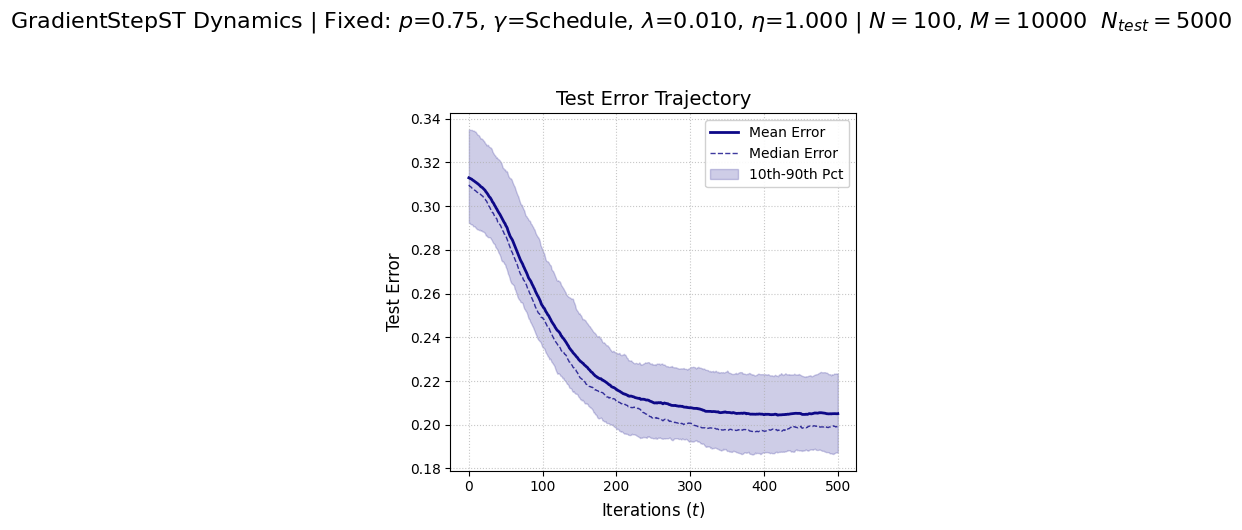

In [23]:
# Create a linear decay schedule for lambda
gamma_schedule = np.linspace(0.1, 2, T )

base_params = {
    'p': 0.75,
    'gamma': gamma_schedule,
    'lambda': 0.01,
    'eta': 1.0
}

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## Varying $\lambda$

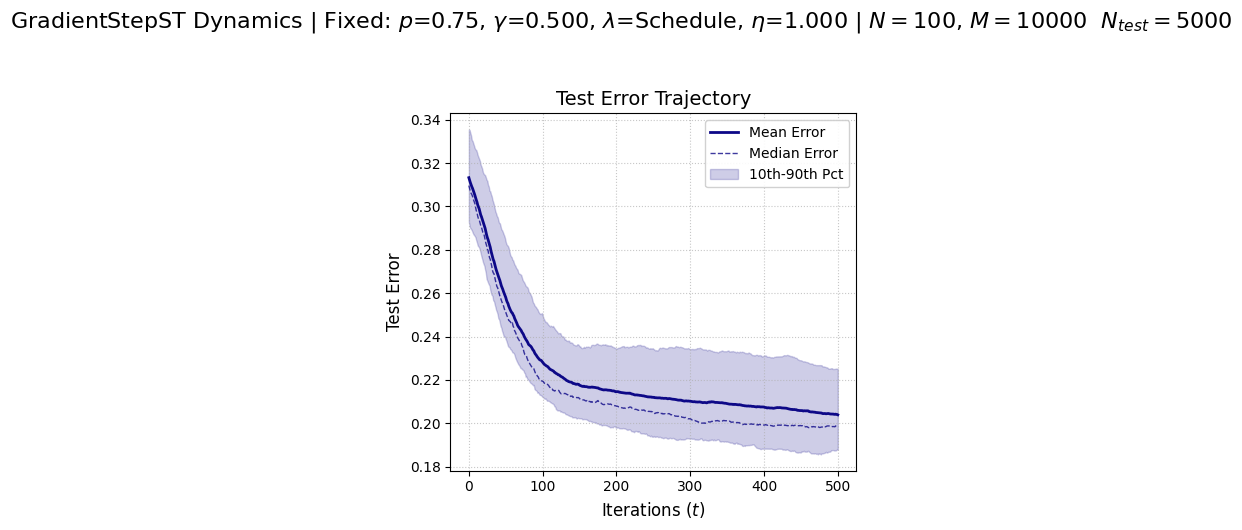

In [31]:
# Create a linear decay schedule for lambda
lambda_schedule = np.linspace(0.02, 0.0001, T+1)

base_params = {
    'p': 0.75,
    'gamma': 0.5,
    'lambda': lambda_schedule,
    'eta': 1.0
}

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)

## Varying $\eta$

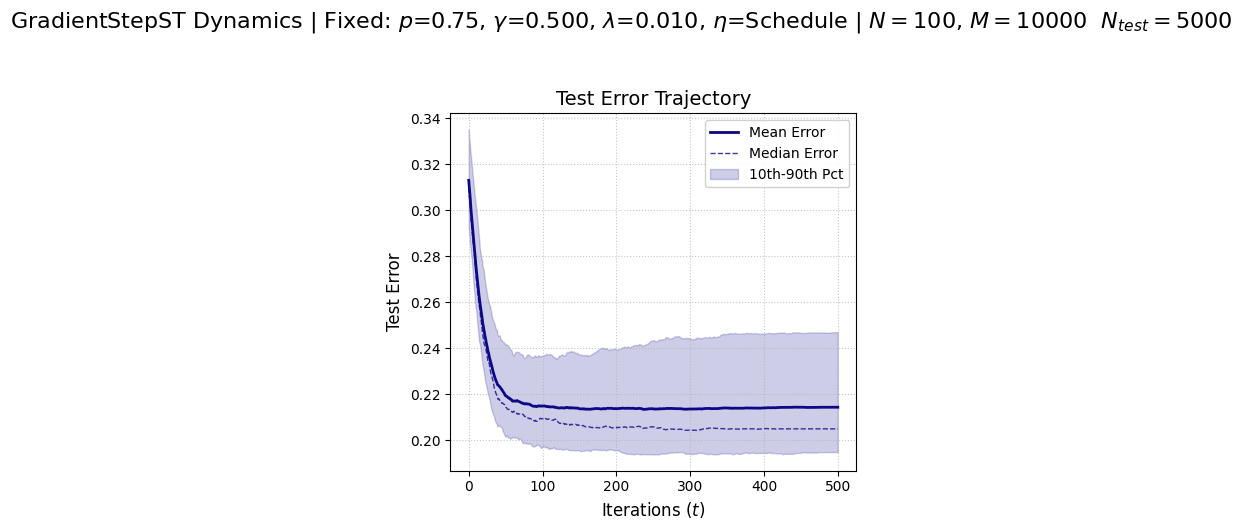

In [34]:
# Create a linear decay schedule for lambda
eta_schedule = np.linspace(5, 0.1, T)

base_params = {
    'p': 0.75,
    'gamma': 0.5,
    'lambda': 0.01,
    'eta': eta_schedule
}

# Run Single (Omit sweep parameters)
res_single = run_experiment(
    data_gen=data,
    algorithm=GradientStepSelfTrainer,
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot Single
plot_experiment(
    res_single, 
    base_params=base_params, 
    N=N, M=M, N_test=N_test, T=T,
    algorithm_name='GradientStepST'
)